# 6. Shoreline validation

How well does the georeferencing place the thermal image on the ground? A land-water boundary in the image must fall onto the coastline after georeferencing. Coastline passages of both campaigns are labelled by hand in `shoreline_calibration.ipynb`, the interactive notebook next to this one (needs `ipympl`). This page compares the labelled pixels with the reference shoreline, the OpenStreetMap coastline (© OpenStreetMap contributors, [ODbL](https://www.openstreetmap.org/copyright)), for `georef_paulr` projecting onto the EGM96 geoid, i.e. sea level. The functions are in `velox_tools.shoreline`.

In short, with the labels so far:

- Without any calibration, the labelled shoreline pixels lie a median **19 m from the reference in PERCUSION**, less than two pixels, and **55 m in HALO-(AC)³**, about five pixels.
- PERCUSION needs no correction. The HALO-(AC)³ images are shifted about 55 m to port, and a correction of the boresight angles and the frame times brings their median to 28 m, or 29 m on flights left out of the fit.
- What remains in HALO-(AC)³ are along-track shifts that differ from flight to flight, most likely timing.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely
from matplotlib.collections import LineCollection
from pyproj import CRS, Geod, Transformer
from shapely.ops import transform

from velox_tools import shoreline

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.width', 200)

CHANNEL = 1                                       # the labelled channel
SKY = ('clear', 'partly cloudy', 'unrated')       # events rated cloudy or unusable are left out
events = shoreline.read_events()                  # coastline passages of all flights (find_all_events)
store = shoreline.LabelStore('shoreline_labels')  # labels and sky ratings of shoreline_calibration.ipynb

## Coastline passages

`find_all_events` searches the flight tracks for *events*: stretches during which at least 1 km of reference shoreline runs through the inner 70 % of the frame. `cache_frames` stores a few frames of each. The sky of every event can be rated while labelling. Events rated *cloudy* or *unusable* (sea ice, glacier fronts, no thermal contrast) are left out here; every labelled event that is not, rated *clear*, *partly cloudy* or not rated at all, is used. Most tropical PERCUSION flights have no coastline passages at all. The final data leave out their ascents and descents. The map shows every passage found. The coloured ones are rated clear or partly cloudy and labelled, and they make up the validation below.

In [2]:
table = events[['campaign', 'flight', 'event_id']].copy()
table['sky'] = [store.sky(e) for e in table['event_id']]
pixels = store.points[store.points['channel'] == CHANNEL].groupby('event_id').size()
table['pixels'] = table['event_id'].map(pixels).fillna(0).astype(int)
usable = table['sky'].isin(SKY)
table.groupby('campaign').apply(lambda g: pd.Series({
    'flights': g['flight'].nunique(),
    'events': len(g),
    'rated': int((g['sky'] != 'unrated').sum()),
    'rated cloudy or unusable': int((~usable[g.index]).sum()),
    'labelled and used': int((usable[g.index] & (g['pixels'] > 0)).sum()),
    'labelled pixels used': int(g.loc[usable[g.index], 'pixels'].sum()),
}), include_groups=False)

,flights,events,rated,rated cloudy or unusable,labelled and used,labelled pixels used
campaign,,,,,,
HALO-AC3,16,280,186,153,86,4112
PERCUSION,12,242,116,80,25,920


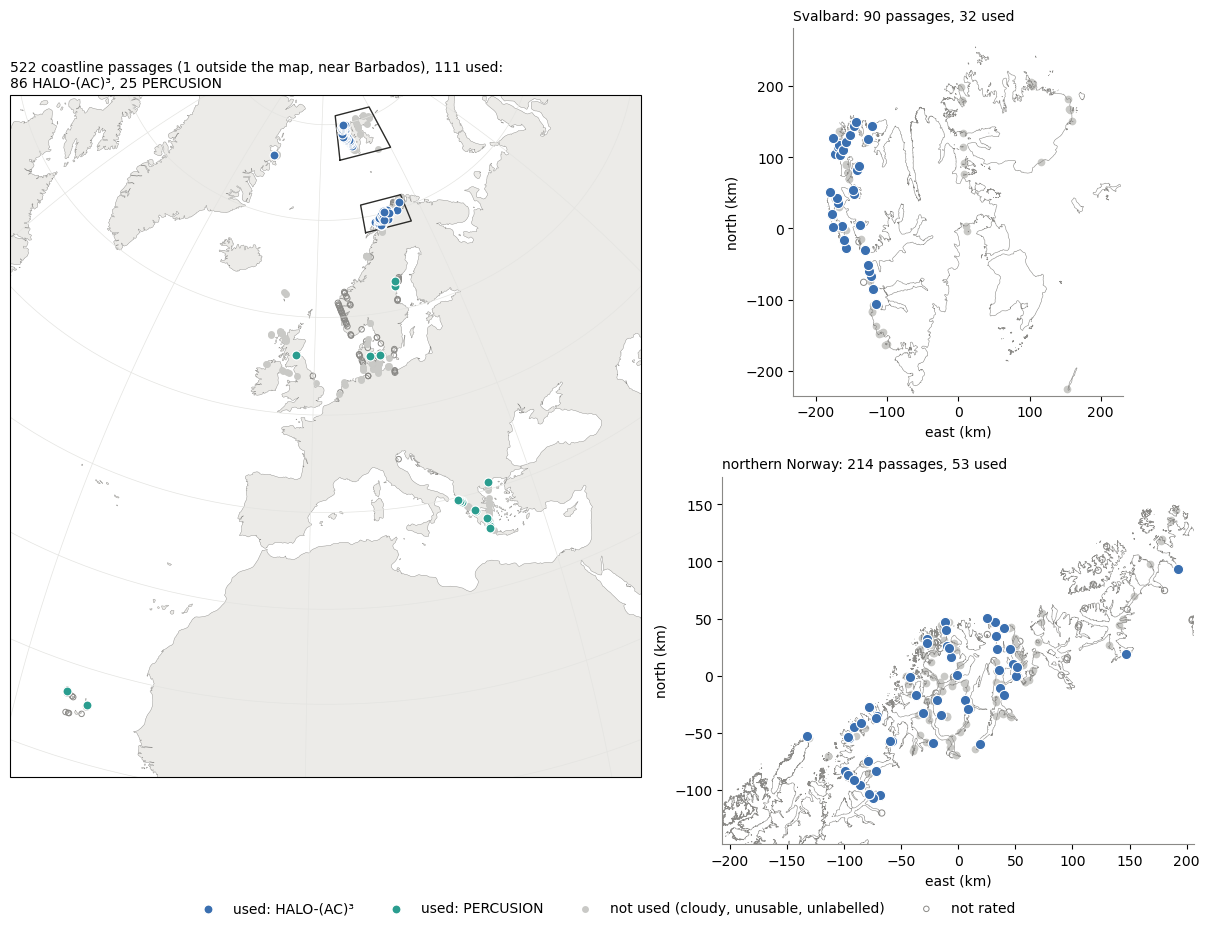

In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

CAMPAIGN_COLOUR = {'HALO-AC3': '#3a6fb0', 'PERCUSION': '#2a9d8f'}
NAME = {'HALO-AC3': 'HALO-(AC)³', 'PERCUSION': 'PERCUSION'}
REGIONS = {'Svalbard': (8, 76.2, 30, 80.9), 'northern Norway': (13, 68.4, 26, 71.3)}

passages = table.merge(events[['event_id', 'lat', 'lon']])
passages['status'] = np.select(
    [usable & (passages['pixels'] > 0), passages['sky'] != 'unrated'], ['used', 'not used'], 'not rated')
lonlat = ccrs.PlateCarree()


def draw_passages(ax, p, size=34, **kwargs):
    # not rated: open grey; rated but not used: light grey; used: filled in the campaign colour
    g = p[p['status'] == 'not rated']
    ax.scatter(g['lon'], g['lat'], s=size * 0.6, facecolors='none', edgecolors='#8a8986', linewidths=0.7,
               label='not rated', **kwargs)
    g = p[p['status'] == 'not used']
    ax.scatter(g['lon'], g['lat'], s=size * 0.6, color='#c9c9c6', label='not used (cloudy, unusable, unlabelled)',
               **kwargs)
    for c, g in p[p['status'] == 'used'].groupby('campaign'):
        ax.scatter(g['lon'], g['lat'], s=size * 1.6, color=CAMPAIGN_COLOUR[c], edgecolors='white', linewidths=0.8,
                   zorder=4, label=f'used: {NAME[c]}', **kwargs)


EXTENT = (-30, 34, 12, 82)  # lon/lat of the overview
fig = plt.figure(figsize=(12, 9.2), layout='constrained')
grid = fig.add_gridspec(2, 2, width_ratios=[1.3, 1])

# overview: all passages of both campaigns
ax = fig.add_subplot(grid[:, 0], projection=ccrs.LambertAzimuthalEqualArea(central_longitude=2, central_latitude=50))
ax.set_extent(EXTENT, lonlat)
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#ecebe8', edgecolor='#8a8986', linewidth=0.3)
ax.gridlines(color='#e4e4e1', linewidth=0.5)
draw_passages(ax, passages, size=26, transform=lonlat)
for region, (lon0, lat0, lon1, lat1) in REGIONS.items():
    ax.plot([lon0, lon1, lon1, lon0, lon0], [lat0, lat0, lat1, lat1, lat0], color='#2b2b29', lw=1, transform=lonlat)
used = passages[passages['status'] == 'used']
outside = ~(passages['lon'].between(*EXTENT[:2]) & passages['lat'].between(*EXTENT[2:]))
ax.set_title(f"{len(passages)} coastline passages ({outside.sum()} outside the map, near Barbados), {len(used)} used:\n"
             + ', '.join(f"{(used['campaign'] == c).sum()} {NAME[c]}" for c in NAME), loc='left', fontsize=10)
handles, labels = ax.get_legend_handles_labels()
order = [labels.index(k) for k in ['used: HALO-(AC)³', 'used: PERCUSION', 'not used (cloudy, unusable, unlabelled)',
                                   'not rated']]
fig.legend([handles[i] for i in order], [labels[i] for i in order], frameon=False, loc='outside lower center', ncols=4)

# Svalbard and northern Norway with the OpenStreetMap coastline, in a local projection (km)
for k, (region, (lon0, lat0, lon1, lat1)) in enumerate(REGIONS.items()):
    ax = fig.add_subplot(grid[k, 1])
    crs = CRS.from_proj4(f'+proj=aeqd +lat_0={(lat0 + lat1) / 2} +lon_0={(lon0 + lon1) / 2} +datum=WGS84 +units=km')
    to_km = Transformer.from_crs('EPSG:4326', crs, always_xy=True).transform
    for line in shoreline.read_shoreline((lon0, lat0, lon1, lat1)):
        ax.plot(*transform(to_km, shapely.simplify(line, 0.001)).xy, color='#8a8986', lw=0.4)
    inside = passages[passages['lon'].between(lon0, lon1) & passages['lat'].between(lat0, lat1)].copy()
    inside['lon'], inside['lat'] = to_km(inside['lon'].to_numpy(), inside['lat'].to_numpy())
    draw_passages(ax, inside)
    x, y = to_km([lon0, lon1, lon0, lon1], [lat0, lat0, lat1, lat1])
    ax.set(aspect='equal', xlim=(min(x) + 60, max(x) - 60), ylim=(min(y), max(y)), xlabel='east (km)',
           ylabel='north (km)')
    ax.set_title(f"{region}: {len(inside)} passages, {(inside['status'] == 'used').sum()} used", loc='left',
                 fontsize=10)
    ax.spines[['left', 'bottom']].set_color('#8a8986')

## Labelled frames

In each usable frame, shoreline pixels are picked in the detector image, without the reference line in view. *Suggest edges* proposes candidates: the strongest thermal edge within ±300 m perpendicular to the reference. Suggestions are located by the image alone and are reviewed by hand: wrong ones (cloud edges, sea ice) are removed. Three labelled frames, the detector image on the left (flight direction up, starboard right) and the georeferenced frame with the reference shoreline on the right:

In [4]:
from io import BytesIO

from IPython.display import Image, display


def local(lat, lon):
    # lon/lat -> metres east/north of (lat, lon)
    crs = CRS.from_proj4(f'+proj=aeqd +lat_0={lat} +lon_0={lon} +datum=WGS84 +units=m')
    return Transformer.from_crs('EPSG:4326', crs, always_xy=True).transform


def corners(centres):
    # pixel corners of a curvilinear grid of pixel centres
    p = np.pad(centres, 1, mode='edge')
    p[0, 1:-1], p[-1, 1:-1] = 2 * centres[0] - centres[1], 2 * centres[-1] - centres[-2]
    p[:, 0], p[:, -1] = 2 * p[:, 1] - p[:, 2], 2 * p[:, -2] - p[:, -3]
    return (p[:-1, :-1] + p[1:, :-1] + p[:-1, 1:] + p[1:, 1:]) / 4


def load_example(event_id, correction=None):
    # frame, labels and geometry (km east/north of the aircraft) of the most labelled frame of an event
    p = store.points[(store.points['event_id'] == event_id) & (store.points['channel'] == CHANNEL)]
    time = p['time'].value_counts().index[0]
    p = p[p['time'] == time]
    frames, coast = shoreline.load_event(event_id, CHANNEL)
    bt = frames['BT_2D'].sel(time=np.datetime64(time)).values
    event = events.set_index('event_id').loc[event_id]
    to_local = local(event['lat'], event['lon'])
    km = lambda x, y: tuple(np.asarray(v) / 1e3 for v in to_local(x, y))
    geo = {}
    for name, c in [('before', None), ('after', correction)]:
        g = shoreline.georef_corrected(time, CHANNEL, c)
        geo[name] = km(g['lon'].values, g['lat'].values)
    return dict(event=event, time=time, bt=bt, x=p['x'].to_numpy(int), y=p['y'].to_numpy(int),
                source=p['source'].to_numpy(), coast=transform(km, coast), geo=geo)


def limits(bt):
    return np.nanpercentile(bt, [2, 98])


def draw_detector(ax, ex):
    ax.imshow(ex['bt'].T, origin='lower', cmap='gray', vmin=limits(ex['bt'])[0], vmax=limits(ex['bt'])[1],
              interpolation='nearest')
    ax.scatter(ex['x'], ex['y'], s=14, facecolors='none', edgecolors='#3a6fb0', linewidths=1.1)
    ax.set_xlim(634.5, -0.5)  # starboard (x = 0) on the right
    ax.set(xlabel='x pixel', ylabel='y pixel (flight direction ↑)', xticks=[0, 300, 600], yticks=[0, 250, 500])


def draw_map(ax, ex, which='before', box=None, window=None):
    east, north = ex['geo'][which]
    vmin, vmax = limits(ex['bt'])
    step = 1 if window else 2
    ax.pcolormesh(corners(east[::step, ::step]), corners(north[::step, ::step]), ex['bt'][::step, ::step],
                  cmap='gray', vmin=vmin, vmax=vmax, shading='flat', rasterized=True)
    for part in shapely.get_parts(ex['coast']):
        ax.plot(*part.xy, color='#eb6834', lw=1.6 if window else 1.1)
    px, py = east[ex['x'], ex['y']], north[ex['x'], ex['y']]
    points = shapely.points(np.column_stack([px, py]))
    offsets = shapely.get_coordinates(shapely.shortest_line(points, ex['coast'])).reshape(-1, 2, 2)
    distance = shapely.distance(points, ex['coast']) * 1e3
    if window:
        ax.add_collection(LineCollection(offsets, colors='#3a6fb0', linewidths=1.4, zorder=3))
    ax.scatter(px, py, s=16 if window else 7, color='#3a6fb0', edgecolors='white', linewidths=0.5, zorder=4)
    ax.set(aspect='equal', xlabel='east (km)', ylabel='north (km)')
    if window:
        ax.set(xlim=window[0], ylim=window[1])
    else:
        ax.set(xlim=(east.min(), east.max()), ylim=(north.min(), north.max()))
    if box:
        (x0, x1), (y0, y1) = box
        ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color='white', lw=1.2)
    return distance


def describe(ex, sep=', '):
    e = ex['event']
    return (f"{e['campaign']} {e['flight']}  {pd.Timestamp(ex['time']):%Y-%m-%d %H:%M:%S}{sep}"
            f"heading {e['hdg']:.0f}°, {e['alt'] / 1e3:.1f} km")


def show_jpeg(fig, quality=88):
    # image-heavy figures are stored as JPEG: a third of the PNG size
    buffer = BytesIO()
    fig.savefig(buffer, format='jpg', bbox_inches='tight', pil_kwargs=dict(quality=quality))
    plt.close(fig)
    display(Image(buffer.getvalue()))


def before_after(row, ex):
    # full frame with the zoom box, and the zoom before and after the correction
    window = densest_window(ex)
    draw_map(row[0], ex, 'before', box=window)
    row[0].set_title(describe(ex, sep='\n'), loc='left', fontsize=10)
    for ax, which in zip(row[1:], ['before', 'after']):
        d = draw_map(ax, ex, which, window=window)
        ax.set_title(f'{which}: median {np.median(d):.0f} m', loc='left', fontsize=10)


def densest_window(ex, which='before', size=1.6):
    # the size x size km window around the labelled pixel with the most labelled neighbours
    east, north = ex['geo'][which]
    p = np.column_stack([east[ex['x'], ex['y']], north[ex['x'], ex['y']]])
    count = (np.abs(p[:, None] - p[None]).max(axis=-1) < size / 2).sum(1)
    cx, cy = p[np.argmax(count)]
    return (cx - size / 2, cx + size / 2), (cy - size / 2, cy + size / 2)

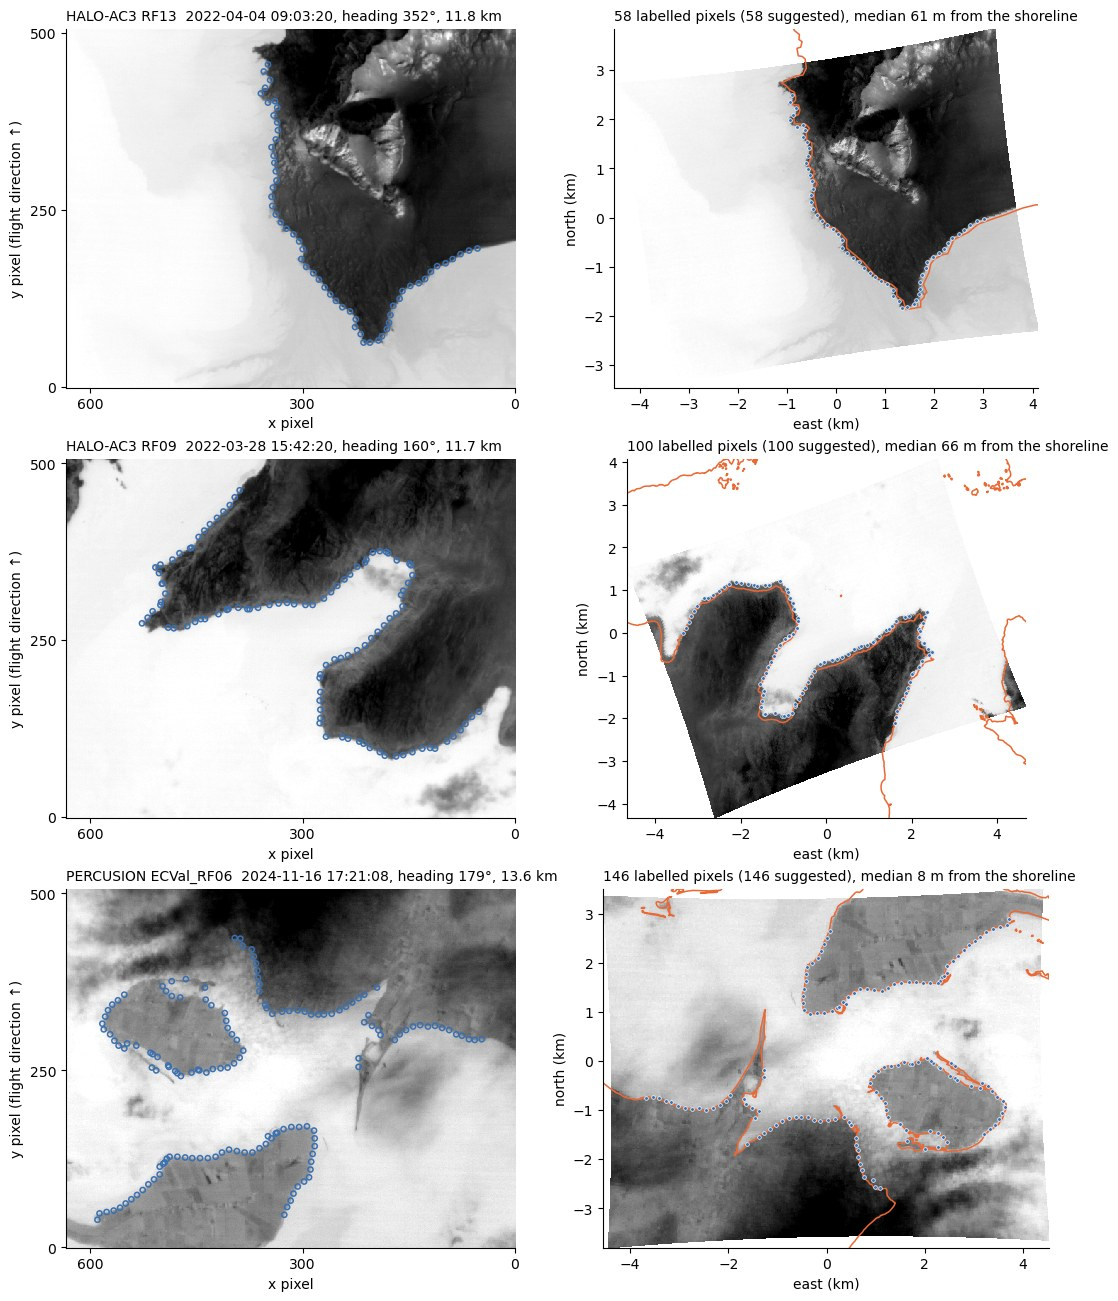

In [5]:
EXAMPLES = ['HALO-AC3_RF13_090320',         # Svalbard, flying along the coast (notebook 03)
            'HALO-AC3_RF09_154220',         # islands off northern Norway
            'PERCUSION_ECVal_RF06_172108']  # Danish coast
examples = {e: load_example(e) for e in EXAMPLES}

fig, axes = plt.subplots(len(EXAMPLES), 2, figsize=(11, 4.3 * len(EXAMPLES)), layout='constrained',
                         gridspec_kw=dict(width_ratios=[1, 1.1]))
for (ax_img, ax_map), ex in zip(axes, examples.values()):
    draw_detector(ax_img, ex)
    d = draw_map(ax_map, ex)
    n_suggested = (ex['source'] == 'suggested').sum()
    ax_img.set_title(describe(ex), loc='left', fontsize=10)
    ax_map.set_title(f"{len(d)} labelled pixels ({n_suggested} suggested), median {np.median(d):.0f} m "
                     'from the shoreline', loc='left', fontsize=10)
show_jpeg(fig)

## How far off is the georeferencing?

The distance of every labelled pixel from the reference shoreline, with `georef_paulr` as shipped, no correction. For scale, the ground size of a nadir pixel of each labelled frame:

In [6]:
frames = shoreline.frames_from_labels(store, sky=SKY, channel=CHANNEL)
by_campaign = {c: [f for f in frames if f.campaign == c] for c in sorted({f.campaign for f in frames})}


def pixel_size(time):
    # mean spacing (m) of the nadir pixel's neighbours in x and y
    g = shoreline.georef_corrected(time, CHANNEL)
    lat, lon = g['lat'].values, g['lon'].values
    geod = Geod(ellps='WGS84')
    return np.mean([geod.inv(lon[317, 253], lat[317, 253], lon[i, j], lat[i, j])[2] for i, j in [(318, 253), (317, 254)]])


distances, rows = {}, []
for c, fr in by_campaign.items():
    distances[c] = d = np.concatenate([f.distances() for f in fr])
    pixel = np.median([pixel_size(f.time) for f in fr])
    rows.append({'campaign': c, 'flights': len({f.flight for f in fr}), 'frames': len(fr), 'pixels': len(d),
                 'median (m)': np.median(d), '68 % (m)': np.percentile(d, 68), '95 % (m)': np.percentile(d, 95),
                 'nadir pixel (m)': pixel, 'median (pixels)': np.median(d) / pixel})
validation = pd.DataFrame(rows).set_index('campaign')
validation.round(1)

,flights,frames,pixels,median (m),68 % (m),95 % (m),nadir pixel (m),median (pixels)
campaign,,,,,,,,
HALO-AC3,13,89,4112,55.2,75.8,128.4,11.0,5.0
PERCUSION,7,25,920,19.2,32.9,111.1,13.2,1.5


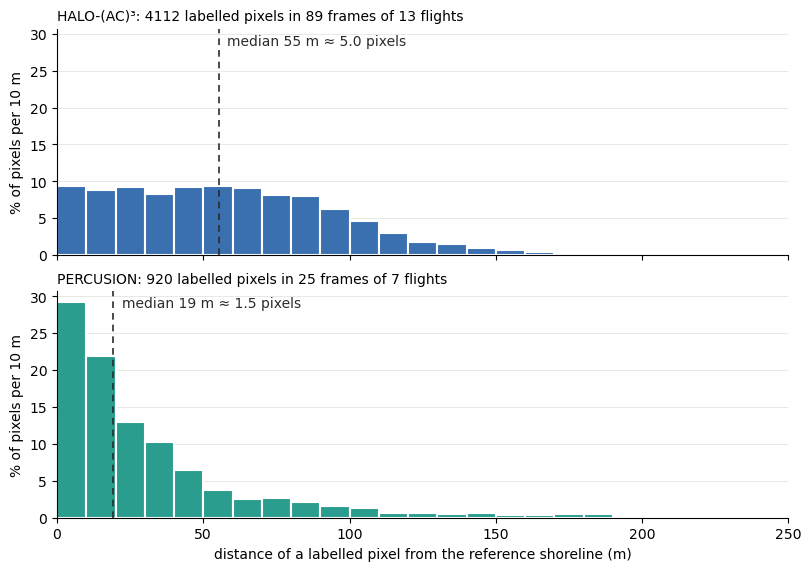

In [7]:
BINS = np.arange(0, 250 + 1, 10)

fig, axes = plt.subplots(len(distances), 1, figsize=(8, 2.8 * len(distances)), sharex=True, sharey=True,
                         layout='constrained')
for ax, (c, d) in zip(axes, distances.items()):
    ax.hist(d, bins=BINS, weights=np.full(len(d), 100 / len(d)), color=CAMPAIGN_COLOUR[c], edgecolor='white', lw=1.5)
    median = np.median(d)
    ax.axvline(median, color='#2b2b29', lw=1.2, ls=(0, (4, 3)))
    ax.annotate(f"median {median:.0f} m ≈ {validation.loc[c, 'median (pixels)']:.1f} pixels", (median, 1), (6, -4),
                xycoords=('data', 'axes fraction'), textcoords='offset points', va='top', color='#2b2b29')
    ax.set_title(f"{NAME[c]}: {len(d)} labelled pixels in {validation.loc[c, 'frames']} frames of "
                 f"{validation.loc[c, 'flights']} flights", loc='left', fontsize=10)
    ax.set_ylabel('% of pixels per 10 m')
    ax.grid(axis='y', color='#e4e4e1', lw=0.6)
    ax.set_axisbelow(True)
axes[-1].set(xlabel='distance of a labelled pixel from the reference shoreline (m)', xlim=(0, 250));

**PERCUSION** is georeferenced to less than two pixels: a median of 19 m, close to the accuracy one can expect from hand-picked pixels and a reference shoreline accurate to about 10 m. **HALO-(AC)³** misses by about five pixels, 55 m. The tails of both distributions (95 % below 120-150 m) come from single frames: cloud edges picked for coast, glacier fronts and tidal flats that differ from the reference, and changes of the coastline since the reference was mapped.

## Where do the pixels miss?

The signed distance of each pixel from the shoreline splits into a shift of the image along and across the track: `d = along · n_along + across · n_across`, where `n` is the unit normal of the shoreline in the aircraft frame (`body_frame_residuals`, `body_frame_shift`). Each error source moves the image in its own way:

| error source | shifts the image | size |
|---|---|---|
| roll offset `droll` | across track | `alt · droll` (12 km · 0.1° ≈ 21 m) |
| pitch offset `dpitch` | along track | `alt · dpitch` |
| time offset `dt` | along track | `gs · dt` (230 m/s · 0.5 s ≈ 115 m) |
| yaw offset `dyaw` | rotates the frame | up to `4.5 km · dyaw` at the edges |

A frame determines both components only if its coast runs in several directions. With a straight coast, only the component across it is known, hence the long error bars of some events.

In [8]:
residuals = shoreline.body_frame_residuals(frames)
shoreline.body_frame_shift(residuals, by='campaign').round(1)

,along,along_err,across,across_err,pixels,conditioning
campaign,,,,,,
HALO-AC3,6.0,1.3,-55.4,1.3,4112.0,1.0
PERCUSION,-1.4,2.3,-5.1,2.4,920.0,0.9


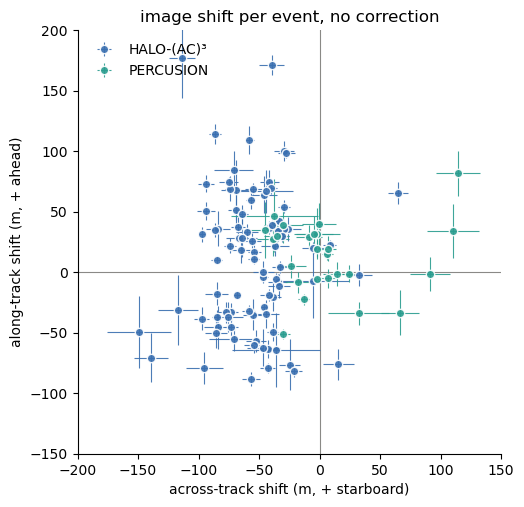

In [9]:
per_event = shoreline.body_frame_shift(residuals, by=['campaign', 'flight', 'event_id']).reset_index()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.axhline(0, color='#8a8986', lw=0.8)
ax.axvline(0, color='#8a8986', lw=0.8)
for c, g in per_event.groupby('campaign'):
    ax.errorbar(g['across'], g['along'], xerr=g['across_err'], yerr=g['along_err'], fmt='o', ms=6,
                color=CAMPAIGN_COLOUR[c], ecolor=CAMPAIGN_COLOUR[c], elinewidth=0.8, alpha=0.9,
                markeredgecolor='white', label=NAME[c])
ax.set(xlabel='across-track shift (m, + starboard)', ylabel='along-track shift (m, + ahead)', aspect='equal',
       xlim=(-200, 150), ylim=(-150, 200), title='image shift per event, no correction')
ax.legend(frameon=False, loc='upper left');

The HALO-(AC)³ images lie to port of the truth in almost every event, by about 55 m over all pixels: the signature of a roll offset. Along track they scatter by ±100 m with no common sign. PERCUSION shows no systematic shift in either direction.

## Correcting HALO-(AC)³

`fit` finds corrections to the boresight angles of all channels (`roll`, `pitch`, `yaw`, in degrees) and to the frame times (`dt`, in seconds) that minimise the distances, with a robust loss. A correction is only trusted if it also helps a flight that was not used to fit it: `jackknife` leaves out one flight at a time, fits the others, and measures the left-out flight. The spread of those fits is the uncertainty given below.

In [10]:
MODELS = {'roll': ('roll',), 'roll + dt': ('roll', 'dt'), 'roll + pitch + yaw': ('roll', 'pitch', 'yaw'),
          'roll + pitch + yaw + dt': ('roll', 'pitch', 'yaw', 'dt')}
rows = []
for c, fr in by_campaign.items():
    rows.append({'campaign': c, 'model': 'none', 'median held-out (m)': np.median(distances[c])})
    for name, params in MODELS.items():
        held, jk_std = shoreline.jackknife(fr, by='flight', params=params)
        # every flight measured with the fit to the other flights
        d = np.concatenate([f.distances(held.loc[f.flight, list(params)].to_dict()) for f in fr])
        rows.append({'campaign': c, 'model': name, 'median held-out (m)': np.median(d),
                     **{k: f'{held[k].mean():+.3f} ± {jk_std[k]:.3f}' for k in params}})
pd.DataFrame(rows).set_index(['campaign', 'model']).fillna('').round(1)

median held-out (m)            roll              dt           pitch             yaw
campaign  model                                                                                                       
HALO-AC3  none                                    55.2                                                                
          roll                                    32.6  -0.370 ± 0.014                                                
          roll + dt                               33.1  -0.371 ± 0.012  -0.016 ± 0.069                                
          roll + pitch + yaw                      31.9  -0.376 ± 0.015                  -0.069 ± 0.089  +0.169 ± 0.089
          roll + pitch + yaw + dt                 29.1  -0.375 ± 0.011  +0.350 ± 0.036  -0.497 ± 0.075  +0.195 ± 0.079
PERCUSION none                                    19.2                                                                
          roll                                    19.9  -0.037 ± 0.031                                                
          roll + dt                               22.3  -0.037 ± 0.034  +0.013 ± 0.058                                
          roll + pitch + yaw                      21.6  -0.031 ± 0.024                  +0.025 ± 0.050  -0.083 ± 0.038
          roll + pitch + yaw + dt                 20.3  -0.017 ± 0.015  -0.489 ± 0.189  +0.500 ± 0.170  -0.099 ± 0.048

For HALO-(AC)³, the roll offset alone accounts for most of it and lowers the held-out median from 55 to 33 m. Pitch, yaw and a time offset together bring it to 29 m. Pitch and `dt` both move the image along track and can be separated only through their different dependence on altitude and ground speed; the 13 labelled flights now cover enough of both for the leave-one-flight-out fits to agree on them (the errors below).

For **PERCUSION**, no model improves the held-out distances: 19 m with the georeferencing as it is, 20 m with any correction. Its calibration is unbiased within the scatter of the labels, so nothing should be changed there.

In [11]:
result = shoreline.fit(by_campaign['HALO-AC3'], params=('roll', 'pitch', 'yaw', 'dt'))
correction = result.correction
print('HALO-AC3 correction:', {k: round(float(v), 3) for k, v in correction.items()})

HALO-AC3 correction: {'roll': -0.375, 'pitch': -0.492, 'yaw': 0.194, 'dt': 0.346}


### Before and after

The correction moves the georeferenced HALO-(AC)³ images to starboard, by the 55 m of the roll offset, and a little along track. Zoomed onto the coast (white boxes), the thermal land-water edge lands on the reference shoreline. The lines join each labelled pixel to the nearest point of the shoreline.

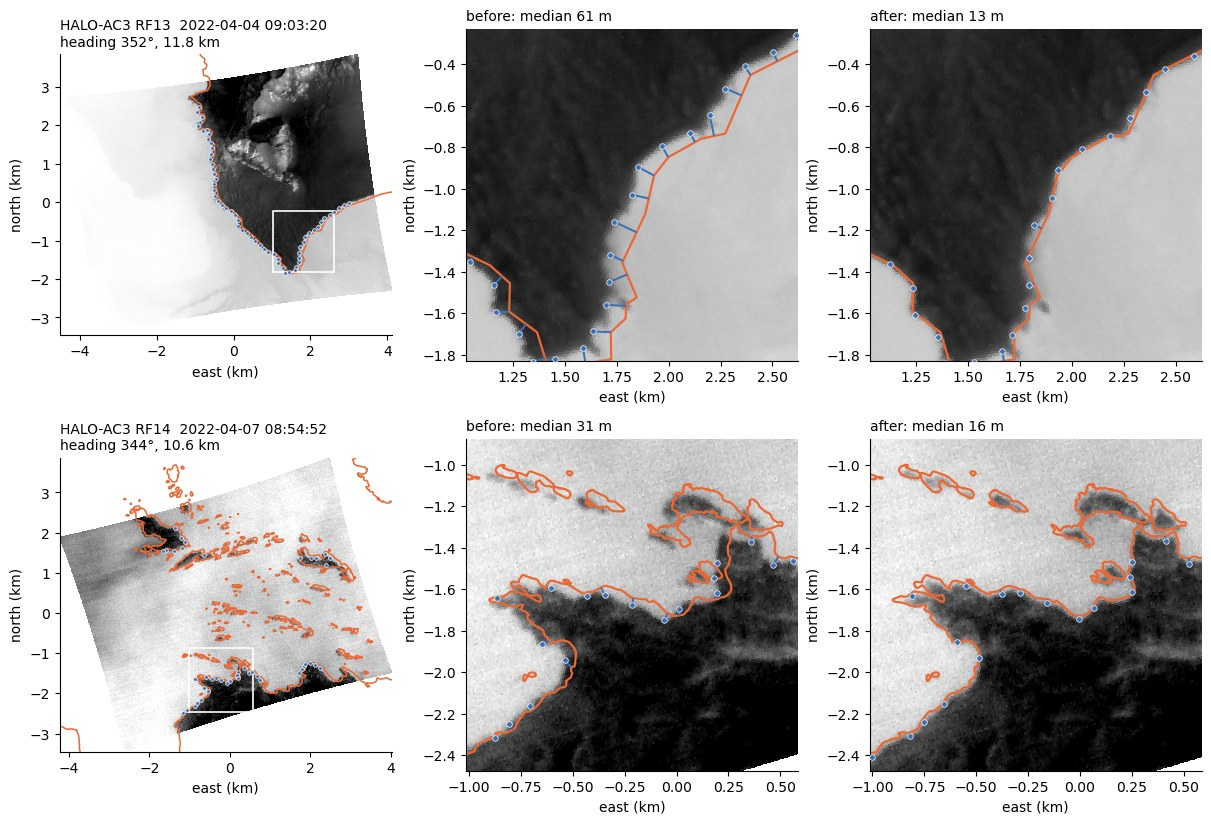

In [12]:
BEFORE_AFTER = ['HALO-AC3_RF13_090320',  # Svalbard, flying along the coast
                'HALO-AC3_RF14_085452']  # northern Norway, crossing the coast
for e in BEFORE_AFTER:
    examples[e] = load_example(e, correction)

fig, axes = plt.subplots(len(BEFORE_AFTER), 3, figsize=(12, 4.1 * len(BEFORE_AFTER)), layout='constrained')
for row, e in zip(axes, BEFORE_AFTER):
    before_after(row, examples[e])
show_jpeg(fig)

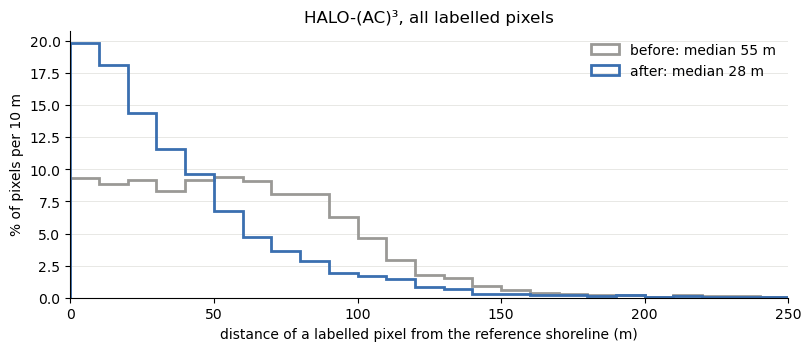

In [13]:
BEFORE, AFTER = '#9a9996', '#3a6fb0'
fig, ax = plt.subplots(figsize=(8, 3.4), layout='constrained')
for k, colour in [('before', BEFORE), ('after', AFTER)]:
    d = getattr(result, k)['distance'].to_numpy()
    ax.hist(d, bins=BINS, weights=np.full(len(d), 100 / len(d)), histtype='step', color=colour, lw=2,
            label=f'{k}: median {np.median(d):.0f} m')
ax.set(xlim=(0, 250), xlabel='distance of a labelled pixel from the reference shoreline (m)',
       ylabel='% of pixels per 10 m', title='HALO-(AC)³, all labelled pixels')
ax.grid(axis='y', color='#e4e4e1', lw=0.6)
ax.legend(frameon=False);

### What remains

After the correction, the across-track shift is gone and the along-track shift is zero on average. The flight means still differ by up to ±50 m, and the events of a flight scatter around them:

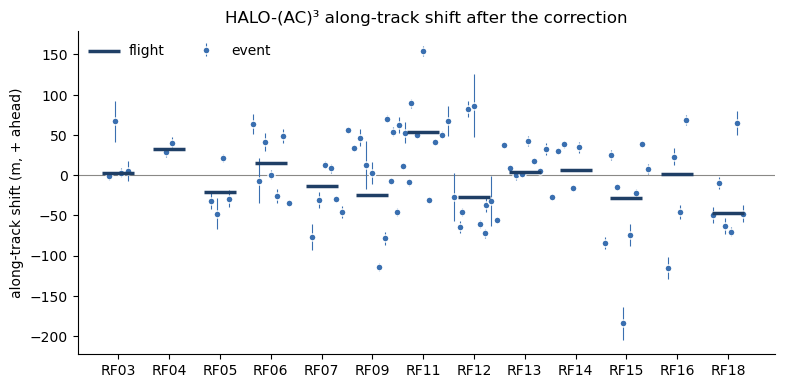

In [14]:
after = shoreline.body_frame_residuals(by_campaign['HALO-AC3'], correction)
per_event = shoreline.body_frame_shift(after, by=['flight', 'event_id']).reset_index()
per_flight = shoreline.body_frame_shift(after, by='flight')

flights = sorted(per_event['flight'].unique())
x = {f: i for i, f in enumerate(flights)}
size = per_event.groupby('flight')['flight'].transform('size')
jitter = per_event.groupby('flight').cumcount() * 0.12 - 0.12 * (size - 1) / 2
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axhline(0, color='#8a8986', lw=0.8)
ax.errorbar(per_event['flight'].map(x) + jitter, per_event['along'], per_event['along_err'], fmt='o', ms=5,
            color='#3a6fb0', elinewidth=0.8, markeredgecolor='white', label='event')
ax.scatter([x[f] for f in per_flight.index], per_flight['along'], marker='_', s=500, color='#1f3f66', lw=2.5,
           zorder=4, label='flight')
ax.set_xticks(range(len(flights)), flights)
ax.set(ylabel='along-track shift (m, + ahead)', title='HALO-(AC)³ along-track shift after the correction')
ax.legend(frameon=False, ncols=2, loc='upper left');

The islands off northern Norway (RF09, the second example above) get worse rather than better: this frame lies further behind the truth along track than the campaign-wide correction accounts for.

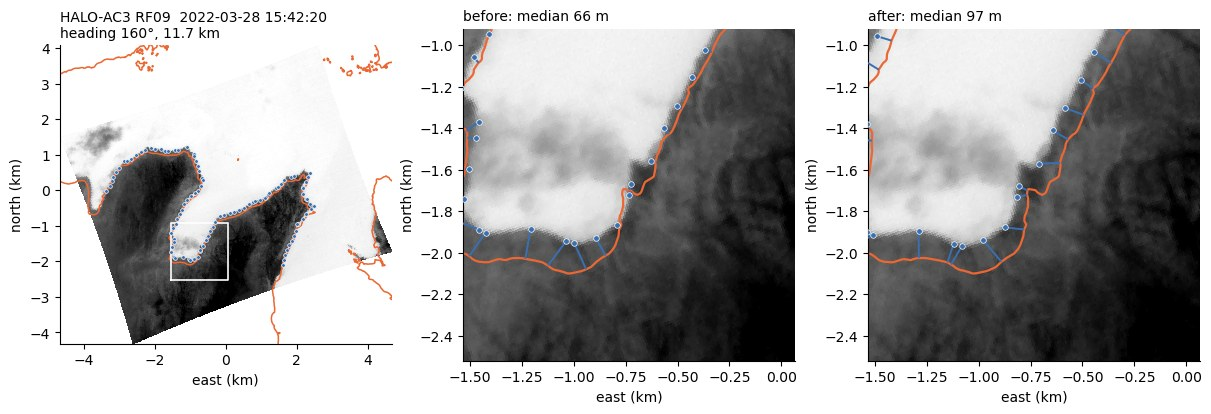

In [15]:
examples['HALO-AC3_RF09_154220'] = load_example('HALO-AC3_RF09_154220', correction)
fig, row = plt.subplots(1, 3, figsize=(12, 4.1), layout='constrained')
before_after(row, examples['HALO-AC3_RF09_154220'])
show_jpeg(fig)

A time offset that differs from flight to flight produces this pattern: 50 m at 230 m/s is 0.2 s. The HALO-(AC)³ frame times are stored in whole seconds, and the VELOX clock may be off differently in every flight. One campaign-wide time offset cannot remove it. A time offset per flight, `fit(..., per_flight_dt=True)`, can be fitted once every flight has labelled passages at two or more headings.

## Result

New `Offset-Angles` of every channel for `velox_tools/data/georef_paulr/velox_mounttree.yaml`: the fitted angles added to the current values. The fitted time offset belongs to the frame times, not to the file. The package applies neither yet.

In [16]:
print(f"frame time offset dt = {correction['dt']:+.3f} s")
pd.DataFrame(result.offset_angles('HALO-AC3')).T

frame time offset dt = +0.346 s


,offset_roll,offset_pitch,offset_yaw
Channel1,-0.145,-3.272,0.204
Channel2,-0.075,-3.242,0.204
Channel3,0.135,-3.212,0.204
Channel5,-0.085,-3.442,0.204
Channel6,0.195,-2.962,0.204
